In [3]:
pip install scikit-optimize

   ---------------------------------------- 0.0/107.8 kB ? eta -:--:--
   --- ------------------------------------ 10.2/107.8 kB ? eta -:--:--
   ------- ------------------------------- 20.5/107.8 kB 330.3 kB/s eta 0:00:01
   ----------- --------------------------- 30.7/107.8 kB 262.6 kB/s eta 0:00:01
   ----------- --------------------------- 30.7/107.8 kB 262.6 kB/s eta 0:00:01
   ----------- --------------------------- 30.7/107.8 kB 262.6 kB/s eta 0:00:01
   -------------- ------------------------ 41.0/107.8 kB 131.3 kB/s eta 0:00:01
   ---------------------- ---------------- 61.4/107.8 kB 182.2 kB/s eta 0:00:01
   ----------------------------- --------- 81.9/107.8 kB 229.7 kB/s eta 0:00:01
   ------------------------------------ - 102.4/107.8 kB 256.7 kB/s eta 0:00:01
   -------------------------------------- 107.8/107.8 kB 250.1 kB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [11]:
import pandas as pd
import numpy as np
import shap
from xgboost import XGBRegressor, plot_importance
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# scikit-optimize imports for Bayesian tuning
from skopt import BayesSearchCV
from skopt.space import Real, Integer
from sklearn.linear_model import LinearRegression

In [ ]:
# Load data
df = pd.read_csv("/Users/Banjo/OneDrive/Desktop/MIDS/Summer 2025/DataSci 207/Final Project/w207FinalProject/data/processed/processed_plays.csv")

# Define features and target
#Train/Validation/Test split (60/20/20)
train_val, test = train_test_split(df, test_size=0.20, random_state=42)
train, val      = train_test_split(train_val, test_size=0.20, random_state=42)

X_train, y_train = train.drop('yardsGained', axis=1), train['yardsGained']
X_val,   y_val   = val.drop('yardsGained', axis=1),   val['yardsGained']
X_test,  y_test  = test.drop('yardsGained', axis=1),  test['yardsGained']



In [ ]:
linreg = LinearRegression()
linreg.fit(X_train, y_train)

# Predict on training set and report R²
train_pred = linreg.predict(X_train)
r2_train = r2_score(y_train, train_pred)
print(f"Linear Regression R² on train data: {r2_train:.3f}")

# Define a loss function returning RMSE and MAE
def compute_loss(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    return rmse, mae

# Evaluate baseline on train and validation sets
train_rmse, train_mae = compute_loss(y_train, train_pred)
val_pred              = linreg.predict(X_val)
val_rmse, val_mae     = compute_loss(y_val, val_pred)

print(f"Baseline losses on train data RMSE: {train_rmse:.3f}  MAE: {train_mae:.3f}")
print(f"Baseline losses on validation data RMSE: {val_rmse:.3f}  MAE: {val_mae:.3f}")

Linear Regression R² on train data: 0.033
Baseline losses on train data RMSE: 8.712  MAE: 5.802
Baseline losses on validation data RMSE: 8.404  MAE: 5.682


In [31]:
model = XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
    n_estimators=100,            
    learning_rate=0.0001,
    early_stopping_rounds=10,     
    eval_metric='rmse'            
)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=10,
             enable_categorical=False, eval_metric='rmse', feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.0001, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [30]:
def evaluate(name, actual, pred):
    rmse = np.sqrt(mean_squared_error(actual, pred))
    mae  = mean_absolute_error(actual, pred)
    r2 = r2_score(actual, pred)
    print(f"{name} → RMSE: {rmse:.3f}, MAE: {mae:.3f}, R²: {r2:.3f}")

evaluate('Train', y_train, model.predict(X_train))
evaluate('Validation', y_val,   model.predict(X_val))
evaluate('Test', y_test,  model.predict(X_test))


Train → RMSE: 8.818, MAE: 5.944, R²: 0.009
Validation → RMSE: 8.470, MAE: 5.782, R²: 0.005
Test → RMSE: 9.164, MAE: 6.066, R²: 0.006


<Figure size 1000x800 with 0 Axes>

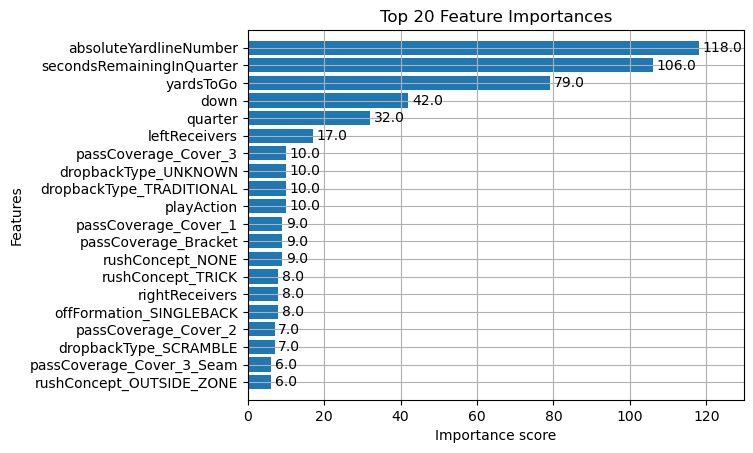

In [ ]:
# Feature importance (top 20)
plt.figure(figsize=(10,8))
plot_importance(model, max_num_features=20, height=0.8)
plt.title('Top 20 Feature Importances')
plt.show()

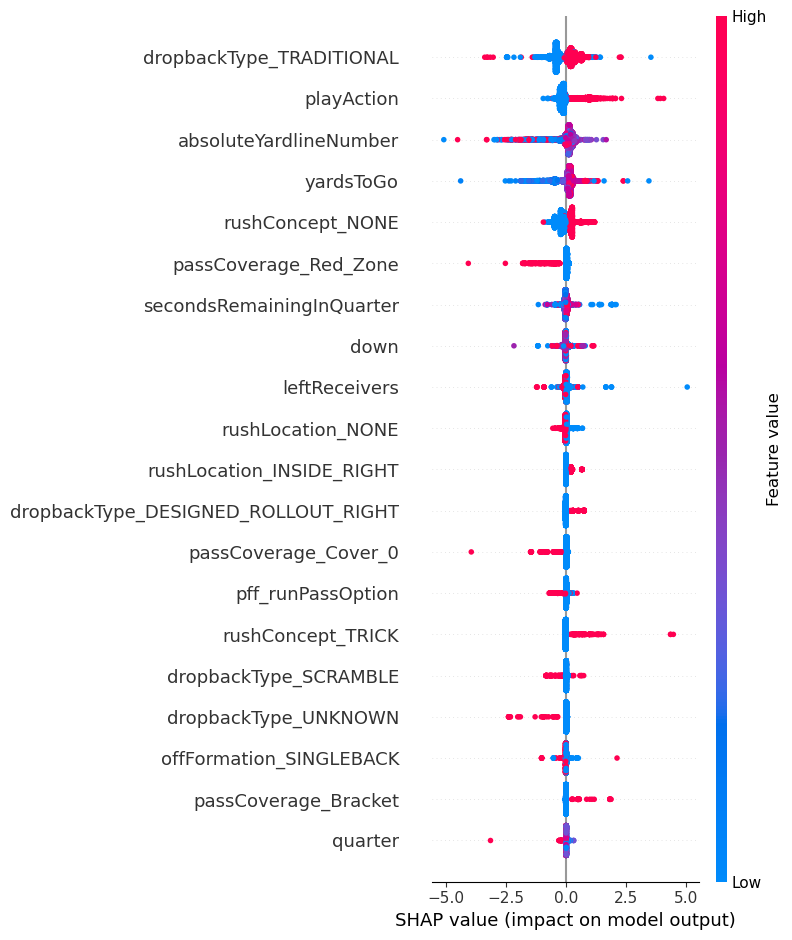

In [ ]:
# SHAP summary plot
explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_train)
shap.summary_plot(shap_values, X_train, show=False)
plt.tight_layout()
plt.show()

In [ ]:
# Hyperparameter tuning via scikit-optimize’s BayesSearchCV
search_spaces = {
    'max_depth':        Integer(3, 10),
    'learning_rate':    Real(0.01, 0.3, prior='log-uniform'),
    'subsample':        Real(0.5, 1.0),
    'colsample_bytree': Real(0.5, 1.0),
    'n_estimators':     Integer(50, 300)
}

bayes_cv = BayesSearchCV(
    estimator=XGBRegressor(objective='reg:squarederror', random_state=42),
    search_spaces=search_spaces,
    n_iter=25,
    scoring='neg_root_mean_squared_error',
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=0
)

bayes_cv.fit(X_train, y_train)
best_params = bayes_cv.best_params_
print("Best hyperparameters found:")
print(best_params)


Best hyperparameters found:
OrderedDict([('colsample_bytree', 0.6128489338057336), ('learning_rate', 0.01), ('max_depth', 3), ('n_estimators', 281), ('subsample', 0.7267272630554792)])


In [ ]:
final_model = XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
    **best_params
)

final_X = pd.concat([X_train, X_val], axis=0)
final_y = pd.concat([y_train, y_val], axis=0)

final_model.fit(final_X, final_y)


# Final evaluation on held-out test set
evaluate('Final Test', y_test, final_model.predict(X_test))

Final Test → RMSE: 9.041, MAE: 5.862, R²: 0.032


Root mean squared error: 9.1296
R squared score:          0.0132


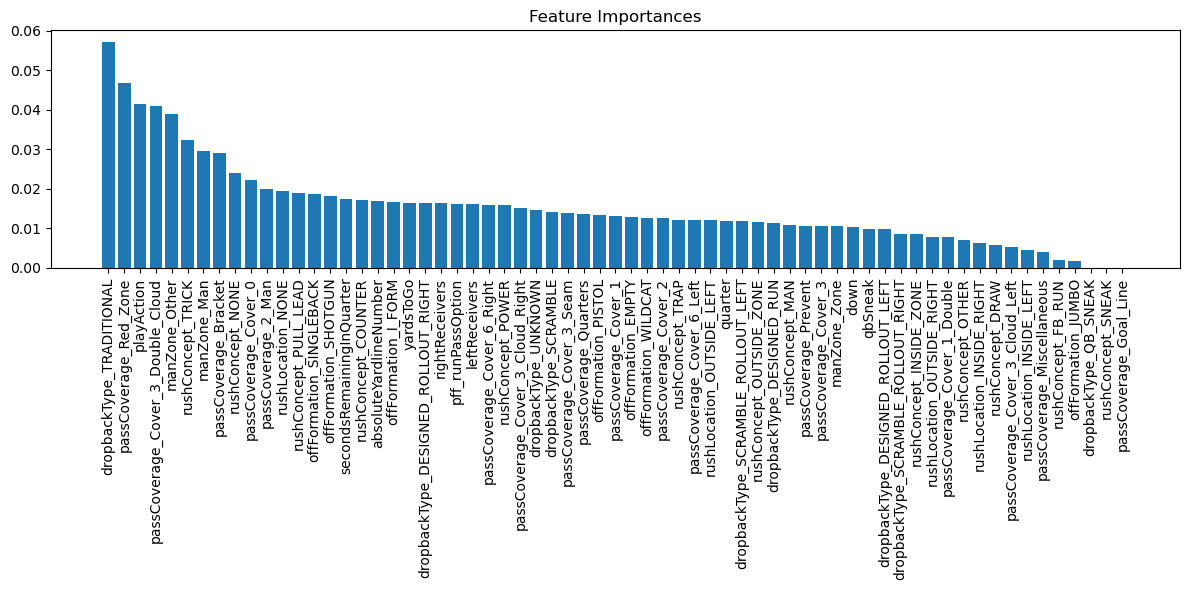